# About this project

Every year the Nobel Prize is given to scientists and scholars in the categories chemistry, literature, physics, physiology or medicine, economics, and peace.


Are there any patterns in the data of the past Nobel laureates?
<br>
What can we learn about the Nobel prize?

### Import Statements

In [27]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

### Notebook Presentation

In [28]:
#enhancing readability
pd.options.display.float_format = '{:,.2f}'.format

### Read the Data

In [29]:
df_data = pd.read_csv('nobel_prize_data.csv')

# Data Exploration & Cleaning

In [82]:
df_data.shape

(962, 18)

In [31]:
df_data.head()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Frédéric Passy,1822-05-20,Paris,France,France,Male,NaN,NaN,NaN,FRA
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Switzerland,Male,NaN,NaN,NaN,CHE


In [32]:
df_data.tail()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
957,2020,Medicine,The Nobel Prize in Physiology or Medicine 2020,“for the discovery of Hepatitis C virus”,1/3,Individual,Michael Houghton,1949-07-02,NaN,United Kingdom,United Kingdom,Male,University of Alberta,Edmonton,Canada,GBR
958,2020,Peace,The Nobel Peace Prize 2020,"“for its efforts to combat hunger, for its con...",1/1,Organization,World Food Programme (WFP),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
959,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery of a supermassive compact o...,1/4,Individual,Andrea Ghez,1965-06-16,"New York, NY",United States of America,United States of America,Female,University of California,"Berkeley, CA",United States of America,USA
960,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery of a supermassive compact o...,1/4,Individual,Reinhard Genzel,1952-03-24,Bad Homburg vor der Höhe,Germany,Germany,Male,University of California,"Los Angeles, CA",United States of America,DEU
961,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery that black hole formation i...,1/2,Individual,Roger Penrose,1931-08-08,Colchester,United Kingdom,United Kingdom,Male,University of Oxford,Oxford,United Kingdom,GBR


### Check for Duplicates

In [33]:
df_data.duplicated().values.any()

np.False_

### Check for NaN Values

In [34]:
df_data.isna().values.any()

np.True_

In [35]:
df_data.isna().sum()

,0
year,0
category,0
prize,0
motivation,88
prize_share,0
laureate_type,0
full_name,0
birth_date,28
birth_city,31
birth_country,28


In [36]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   year                   962 non-null    int64 
 1   category               962 non-null    object
 2   prize                  962 non-null    object
 3   motivation             874 non-null    object
 4   prize_share            962 non-null    object
 5   laureate_type          962 non-null    object
 6   full_name              962 non-null    object
 7   birth_date             934 non-null    object
 8   birth_city             931 non-null    object
 9   birth_country          934 non-null    object
 10  birth_country_current  934 non-null    object
 11  sex                    934 non-null    object
 12  organization_name      707 non-null    object
 13  organization_city      707 non-null    object
 14  organization_country   708 non-null    object
 15  ISO                    

In [37]:
col_subset = ['year','category', 'laureate_type','birth_date','full_name', 'organization_name']
df_data[df_data["birth_date"].isna()][col_subset]
# no birthdate because it's an organization

,year,category,laureate_type,birth_date,full_name,organization_name
24,1904,Peace,Organization,NaN,Institut de droit international (Institute of ...,NaN
60,1910,Peace,Organization,NaN,Bureau international permanent de la Paix (Per...,NaN
89,1917,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
200,1938,Peace,Organization,NaN,Office international Nansen pour les Réfugiés ...,NaN
215,1944,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
237,1947,Peace,Organization,NaN,American Friends Service Committee (The Quakers),NaN
238,1947,Peace,Organization,NaN,Friends Service Council (The Quakers),NaN
283,1954,Peace,Organization,NaN,Office of the United Nations High Commissioner...,NaN
348,1963,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
349,1963,Peace,Organization,NaN,Ligue des Sociétés de la Croix-Rouge (League o...,NaN


In [38]:
col_subset = ['year','category', 'laureate_type','birth_date','full_name', 'organization_name']
df_data[df_data["organization_name"].isna()][col_subset]
# no organisation because no affiliation with one, got it as individual

,year,category,laureate_type,birth_date,full_name,organization_name
1,1901,Literature,Individual,1839-03-16,Sully Prudhomme,NaN
3,1901,Peace,Individual,1822-05-20,Frédéric Passy,NaN
4,1901,Peace,Individual,1828-05-08,Jean Henry Dunant,NaN
7,1902,Literature,Individual,1817-11-30,Christian Matthias Theodor Mommsen,NaN
9,1902,Peace,Individual,1843-05-21,Charles Albert Gobat,NaN
...,...,...,...,...,...,...
932,2018,Peace,Individual,1993-07-02,Nadia Murad,NaN
942,2019,Literature,Individual,1942-12-06,Peter Handke,NaN
946,2019,Peace,Individual,1976-08-15,Abiy Ahmed Ali,NaN
954,2020,Literature,Individual,1943-04-22,Louise Glück,NaN


### Datatype Conversions

#### Convert Year and Birth Date to Datetime

In [39]:
df_data["birth_date"] = pd.to_datetime(df_data["birth_date"])
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    int64         
 1   category               962 non-null    object        
 2   prize                  962 non-null    object        
 3   motivation             874 non-null    object        
 4   prize_share            962 non-null    object        
 5   laureate_type          962 non-null    object        
 6   full_name              962 non-null    object        
 7   birth_date             934 non-null    datetime64[ns]
 8   birth_city             931 non-null    object        
 9   birth_country          934 non-null    object        
 10  birth_country_current  934 non-null    object        
 11  sex                    934 non-null    object        
 12  organization_name      707 non-null    object        
 13  organ

#### Add a Column with the Prize Share as a Percentage

In [40]:
# the nobel prize can be shared by several contributors
seperated_values = df_data["prize_share"].str.split("/", expand=True)
print(seperated_values)
numerator = pd.to_numeric(seperated_values[0])
denomenator = pd.to_numeric(seperated_values[1])
df_data["share_pct"] = numerator / denomenator

     0  1
0    1  1
1    1  1
2    1  1
3    1  2
4    1  2
..  .. ..
957  1  3
958  1  1
959  1  4
960  1  4
961  1  2

[962 rows x 2 columns]


In [41]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    int64         
 1   category               962 non-null    object        
 2   prize                  962 non-null    object        
 3   motivation             874 non-null    object        
 4   prize_share            962 non-null    object        
 5   laureate_type          962 non-null    object        
 6   full_name              962 non-null    object        
 7   birth_date             934 non-null    datetime64[ns]
 8   birth_city             931 non-null    object        
 9   birth_country          934 non-null    object        
 10  birth_country_current  934 non-null    object        
 11  sex                    934 non-null    object        
 12  organization_name      707 non-null    object        
 13  organ

# Nobel Prize Winners by Gender

In [83]:
gender = df_data["sex"].value_counts()
gender

,count
sex,
Male,876
Female,58


In [84]:
figure = px.pie(names=gender.index, values=gender.values, hole=0.5, title="Nobel Prize Winners by Gender")
figure.show()

# Who were the first 3 Women to Win the Nobel Prize?

In [44]:
subset = ["year", "category", "prize", "motivation", "full_name", "birth_country", "organization_name"]
female_winners = df_data[df_data["sex"] == "Female"][subset]
female_winners.head(3)

,year,category,prize,motivation,full_name,birth_country,organization_name
18,1903,Physics,The Nobel Prize in Physics 1903,"""in recognition of the extraordinary services ...","Marie Curie, née Sklodowska",Russian Empire (Poland),NaN
29,1905,Peace,The Nobel Peace Prize 1905,NaN,"Baroness Bertha Sophie Felicita von Suttner, n...",Austrian Empire (Czech Republic),NaN
51,1909,Literature,The Nobel Prize in Literature 1909,"""in appreciation of the lofty idealism, vivid ...",Selma Ottilia Lovisa Lagerlöf,Sweden,NaN


# Find the Repeat Winners

In [45]:
df_data["full_name"].nunique()

955

In [46]:
df_data[df_data["full_name"].duplicated() == True]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
62,1911,Chemistry,The Nobel Prize in Chemistry 1911,"""in recognition of her services to the advance...",1/1,Individual,"Marie Curie, née Sklodowska",1867-11-07,Warsaw,Russian Empire (Poland),Poland,Female,Sorbonne University,Paris,France,POL,1.00
215,1944,Peace,The Nobel Peace Prize 1944,NaN,1/1,Organization,Comité international de la Croix Rouge (Intern...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00
340,1962,Peace,The Nobel Peace Prize 1962,NaN,1/1,Individual,Linus Carl Pauling,1901-02-28,"Portland, OR",United States of America,United States of America,Male,California Institute of Technology (Caltech),"Pasadena, CA",United States of America,USA,1.00
348,1963,Peace,The Nobel Peace Prize 1963,NaN,1/2,Organization,Comité international de la Croix Rouge (Intern...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50
424,1972,Physics,The Nobel Prize in Physics 1972,"""for their jointly developed theory of superco...",1/3,Individual,John Bardeen,1908-05-23,"Madison, WI",United States of America,United States of America,Male,University of Illinois,"Urbana, IL",United States of America,USA,0.33
505,1980,Chemistry,The Nobel Prize in Chemistry 1980,"""for their contributions concerning the determ...",1/4,Individual,Frederick Sanger,1918-08-13,Rendcombe,United Kingdom,United Kingdom,Male,MRC Laboratory of Molecular Biology,Cambridge,United Kingdom,GBR,0.25
523,1981,Peace,The Nobel Peace Prize 1981,NaN,1/1,Organization,Office of the United Nations High Commissioner...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00


In [47]:
is_winner = df_data.duplicated(subset=["full_name"], keep=False)
multiple_winners = df_data[is_winner]
col_subset = ["year", "category", "prize", "motivation", "laureate_type", "full_name"]
multiple_winners[col_subset]

,year,category,prize,motivation,laureate_type,full_name
18,1903,Physics,The Nobel Prize in Physics 1903,"""in recognition of the extraordinary services ...",Individual,"Marie Curie, née Sklodowska"
62,1911,Chemistry,The Nobel Prize in Chemistry 1911,"""in recognition of her services to the advance...",Individual,"Marie Curie, née Sklodowska"
89,1917,Peace,The Nobel Peace Prize 1917,NaN,Organization,Comité international de la Croix Rouge (Intern...
215,1944,Peace,The Nobel Peace Prize 1944,NaN,Organization,Comité international de la Croix Rouge (Intern...
278,1954,Chemistry,The Nobel Prize in Chemistry 1954,"""for his research into the nature of the chemi...",Individual,Linus Carl Pauling
283,1954,Peace,The Nobel Peace Prize 1954,NaN,Organization,Office of the United Nations High Commissioner...
297,1956,Physics,The Nobel Prize in Physics 1956,"""for their researches on semiconductors and th...",Individual,John Bardeen
306,1958,Chemistry,The Nobel Prize in Chemistry 1958,"""for his work on the structure of proteins, es...",Individual,Frederick Sanger
340,1962,Peace,The Nobel Peace Prize 1962,NaN,Individual,Linus Carl Pauling
348,1963,Peace,The Nobel Peace Prize 1963,NaN,Organization,Comité international de la Croix Rouge (Intern...


# Number of Prizes per Category

In [48]:
print(f"There are {df_data['category'].nunique()} categories")

There are 6 categories


In [49]:
prize_per_category = df_data["category"].value_counts()
figure = px.bar(x=prize_per_category.index,
                y=prize_per_category.values,
                title="Number of Nobel Prizes per Category",
                color=prize_per_category.values,
                color_continuous_scale='Aggrnyl',)
figure.update_layout(xaxis_title="Category",
                     yaxis_title="Amount of Prizes",
                     coloraxis_showscale=False)
figure.show()

# Nobel Prize for Economics
Is there a reason for the low number of Nobel Prizes in the category "Economics"?

In [50]:
economics_prizes = df_data[df_data["category"] == "Economics"]
economics_prizes.sort_values("year").head(3)

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
393,1969,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Jan Tinbergen,1903-04-12,the Hague,Netherlands,Netherlands,Male,The Netherlands School of Economics,Rotterdam,Netherlands,NLD,0.50
394,1969,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Ragnar Frisch,1895-03-03,Oslo,Norway,Norway,Male,University of Oslo,Oslo,Norway,NOR,0.50
402,1970,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for the scientific work through which he has ...",1/1,Individual,Paul A. Samuelson,1915-05-15,"Gary, IN",United States of America,United States of America,Male,Massachusetts Institute of Technology (MIT),"Cambridge, MA",United States of America,USA,1.00


The category "Economics" was only added in 1969.

# Male and Female Winners by Category

In [51]:
cat_by_gender = df_data.groupby(["category","sex"],as_index=False).agg({"prize": pd.Series.count})
cat_by_gender = cat_by_gender.sort_values("prize", ascending=False)
cat_by_gender

,category,sex,prize
11,Physics,Male,212
7,Medicine,Male,210
1,Chemistry,Male,179
5,Literature,Male,101
9,Peace,Male,90
3,Economics,Male,84
8,Peace,Female,17
4,Literature,Female,16
6,Medicine,Female,12
0,Chemistry,Female,7


In [52]:
figure = px.bar(x=cat_by_gender["category"],
                y=cat_by_gender["prize"],
                color=cat_by_gender.sex,
                title="Nobel Prize by category per gender")
figure.update_layout(xaxis_title="Category",
                     yaxis_title="Amount of Prizes")
figure.show()

# Number of Prizes Awarded Over Time

In [53]:
ticks = np.arange(1900,2021,5)
ticks

array([1900, 1905, 1910, 1915, 1920, 1925, 1930, 1935, 1940, 1945, 1950,
       1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005,
       2010, 2015, 2020])

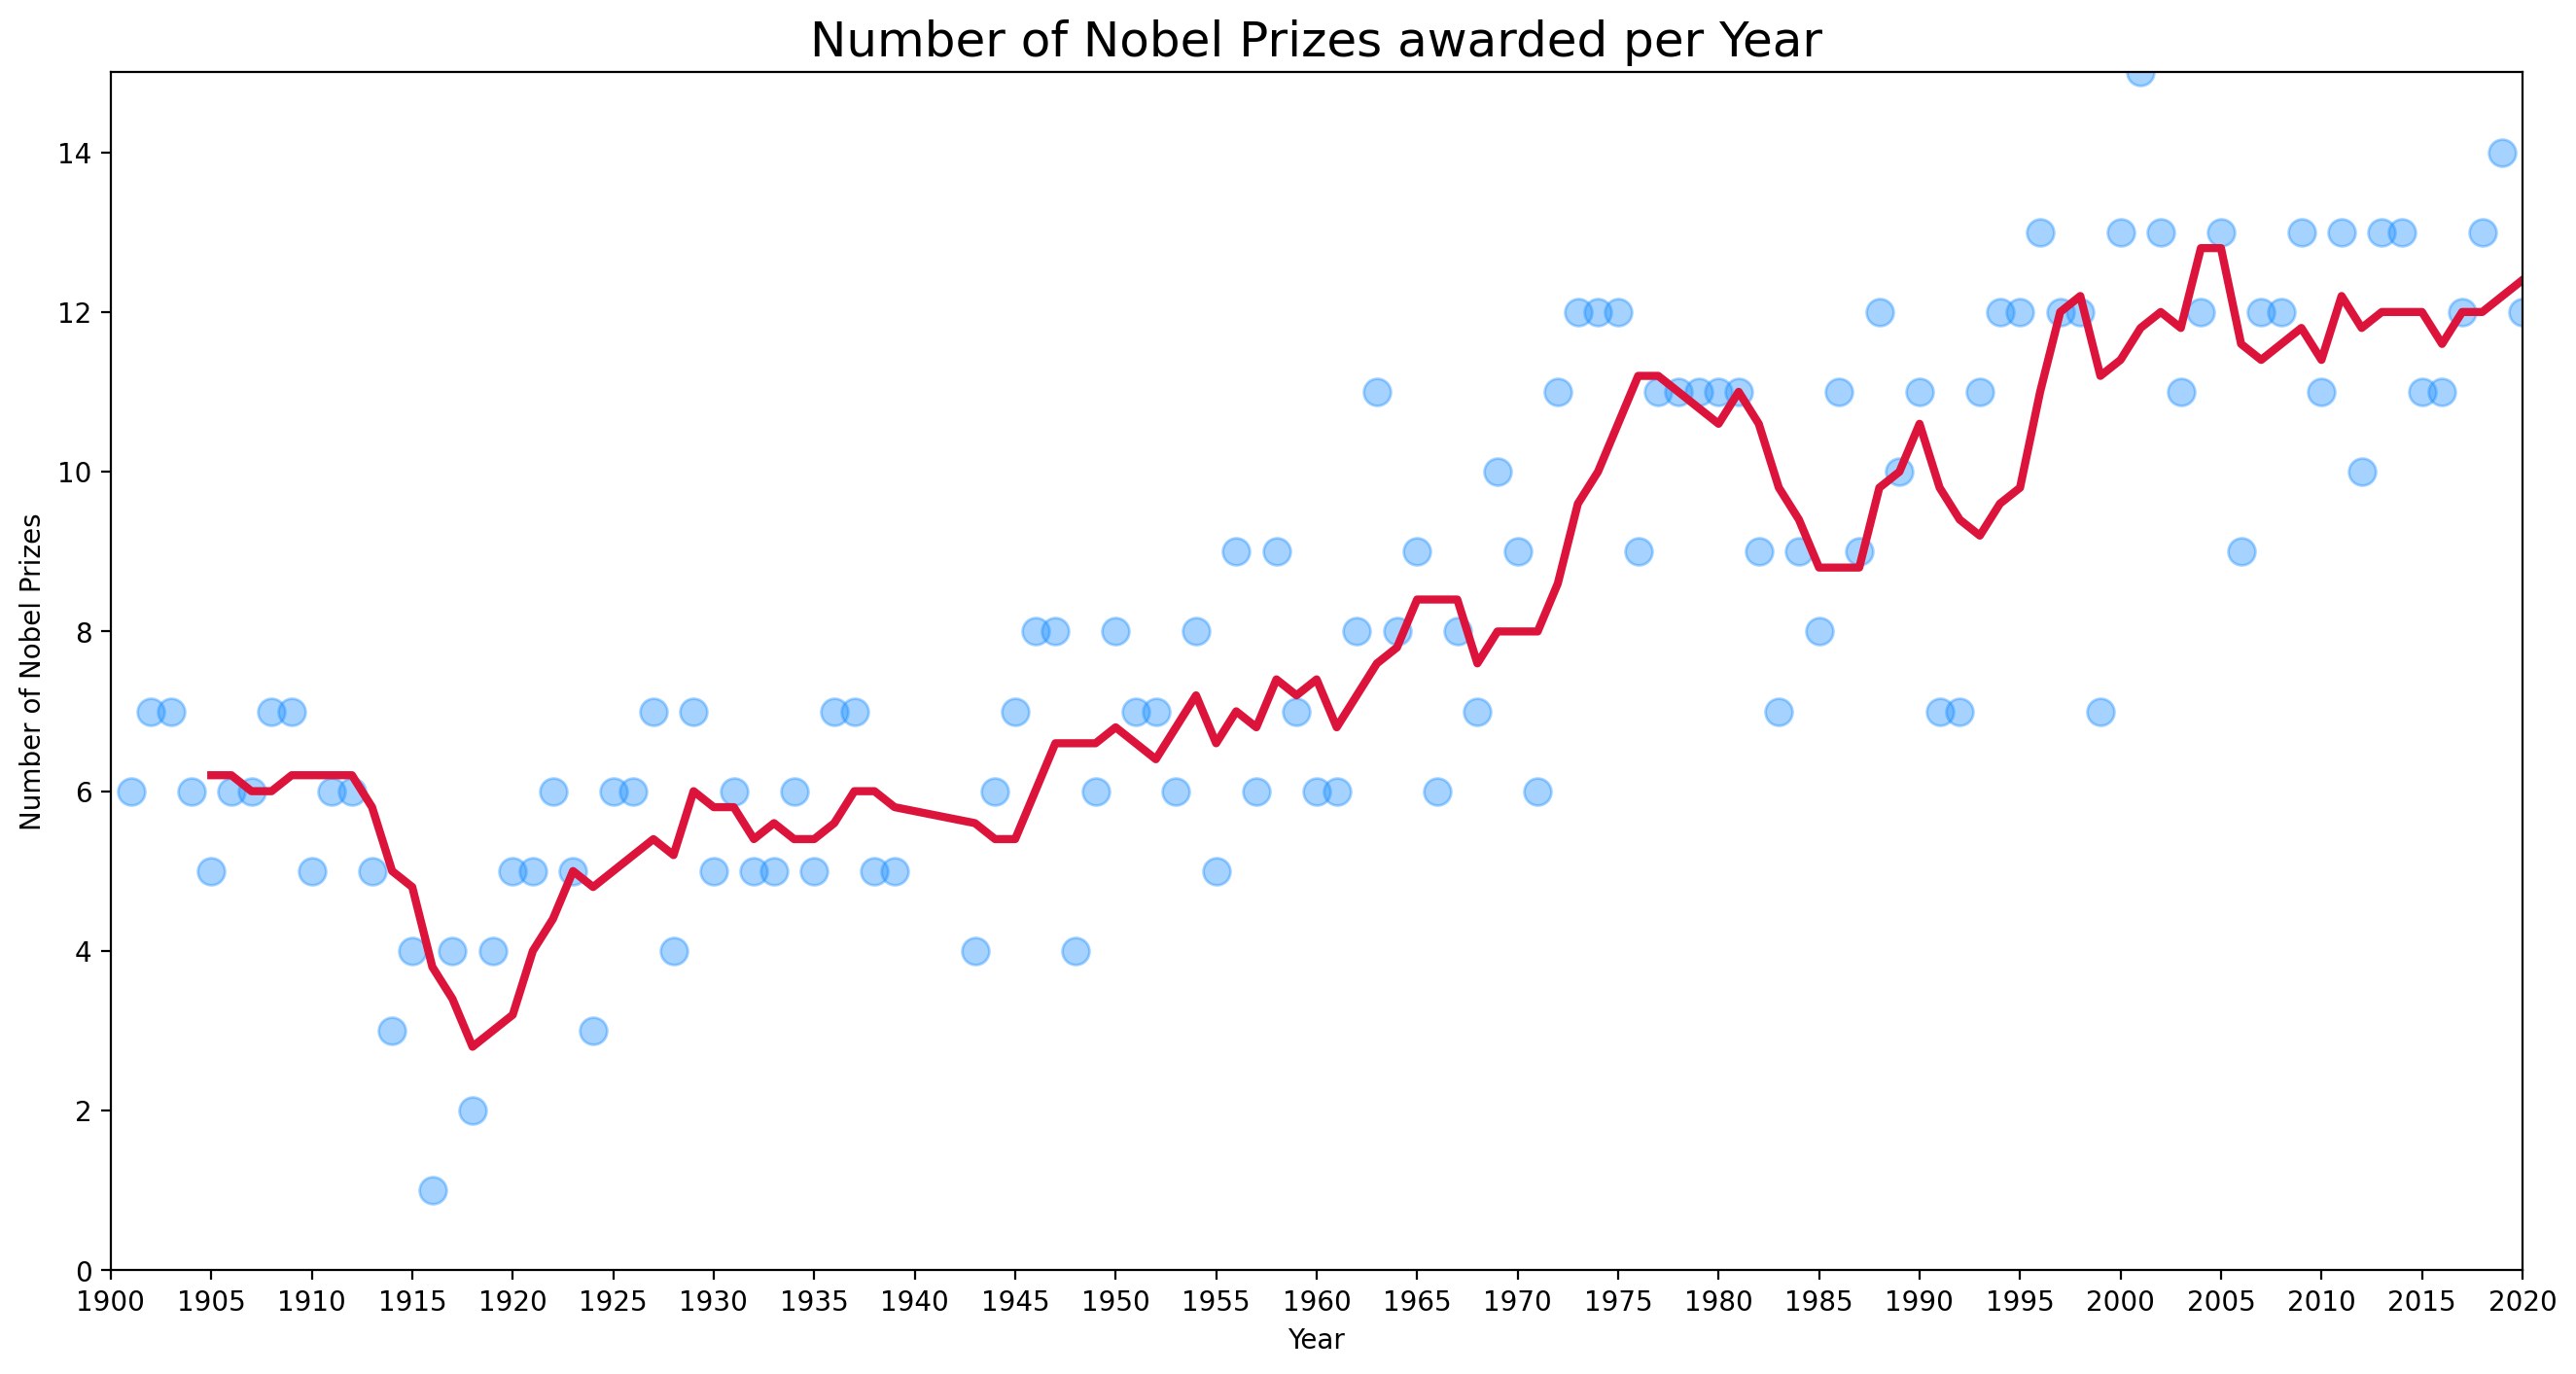

In [54]:
prize_per_year = df_data.groupby("year").agg({"prize": pd.Series.count})
rolling_mean_prize_per_year = prize_per_year.rolling(window=5).mean()
plt.figure(figsize=(16,8), dpi=200)
plt.title("Number of Nobel Prizes awarded per Year", fontsize=18)
plt.xticks(ticks)

ax= plt.gca()
ax.set_xlim(1900,2020)
ax.set_ylim(0,prize_per_year["prize"].max())
ax.set_ylabel("Number of Nobel Prizes")
ax.set_xlabel("Year")
ax.scatter(prize_per_year.index,
            prize_per_year.values,
            color="dodgerblue",
            alpha=0.4,
            s=100)
ax.plot(prize_per_year.index,
         rolling_mean_prize_per_year.values,
         color="crimson",
         linewidth=3)
plt.show()

# Are More Prizes Shared Than Before?

In [55]:
avg_prize_shr = df_data.groupby("year").agg({"share_pct": pd.Series.mean})
rolling_mean_prize_share = avg_prize_shr.rolling(window=5).mean()

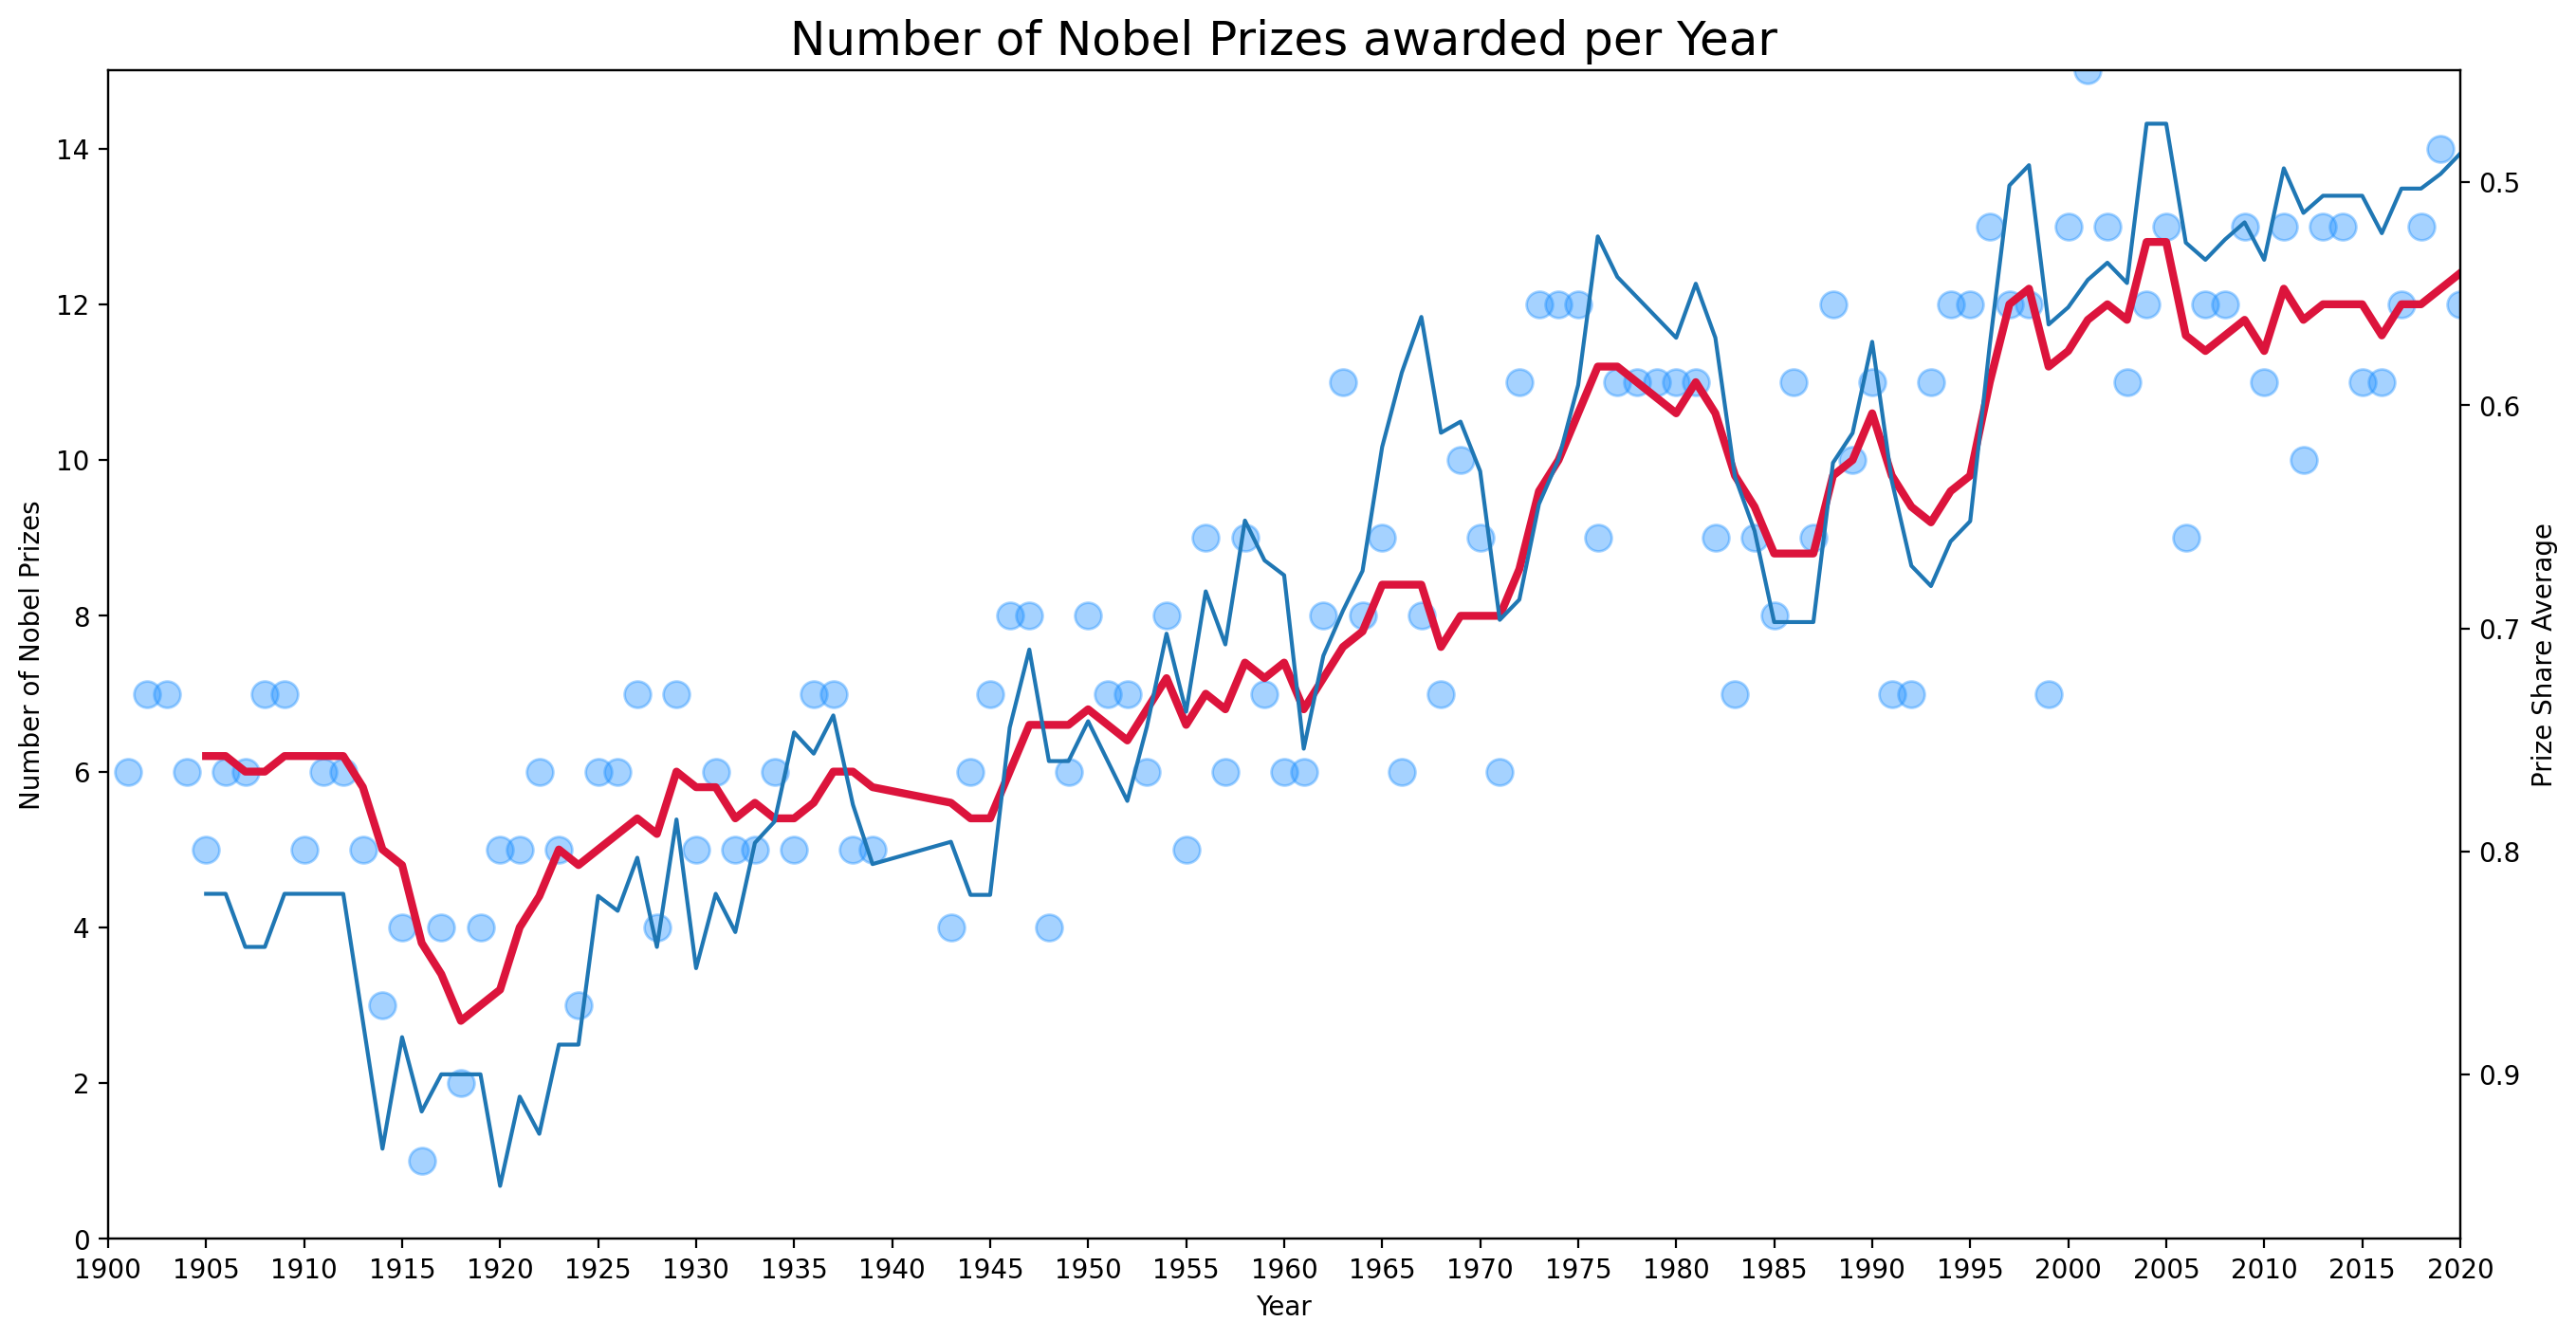

In [56]:
plt.figure(figsize=(16,8), dpi=200)
plt.title("Number of Nobel Prizes awarded per Year", fontsize=18)
plt.xticks(ticks)

ax1= plt.gca()
ax2=ax1.twinx()
ax1.set_xlim(1900,2020)
ax1.set_ylim(0,prize_per_year["prize"].max())
ax1.set_ylabel("Number of Nobel Prizes")
ax1.set_xlabel("Year")
ax2.set_ylabel("Prize Share Average")
ax2.invert_yaxis()
ax1.scatter(prize_per_year.index,
            prize_per_year.values,
            color="dodgerblue",
            alpha=0.4,
            s=100)
ax1.plot(prize_per_year.index,
         rolling_mean_prize_per_year.values,
         color="crimson",
         linewidth=3)
ax2.plot(prize_per_year.index,
         rolling_mean_prize_share.values)
plt.show()

# The Countries with the Most Nobel Prizes

In [57]:
all_countries = df_data.groupby("birth_country_current", as_index=False).agg({"prize": pd.Series.count})
top20_countries = all_countries.sort_values("prize", ascending=False)[:20]
top20_countries.head()

,birth_country_current,prize
74,United States of America,281
73,United Kingdom,105
26,Germany,84
25,France,57
67,Sweden,29


In [58]:
figure = px.bar(x=top20_countries.prize,
                y=top20_countries.birth_country_current,
                orientation="h",
                title="Top 20 Countries by Number of Prizes",
                color=top20_countries.prize,
                color_continuous_scale="viridis")

figure.update_layout(xaxis_title="Number of Prizes",
                     yaxis_title="Country",
                     coloraxis_showscale=False,
                     yaxis={"categoryorder": "total ascending"})

figure.show()

# Number of Prizes Won by Country

In [59]:
countries = df_data.groupby(["birth_country_current", "ISO"], as_index=False).agg({"prize": pd.Series.count})
countries.head()

,birth_country_current,ISO,prize
0,Algeria,DZA,2
1,Argentina,ARG,4
2,Australia,AUS,10
3,Austria,AUT,18
4,Azerbaijan,AZE,1


In [60]:
world_map = px.choropleth(data_frame=countries,
                          locations="ISO",
                          color="prize",
                          hover_name="birth_country_current",
                          color_continuous_scale="matter")
world_map.show()

# In Which Categories are the Different Countries Winning Prizes?

In [61]:
cat_country = df_data.groupby(["birth_country_current", "category"], as_index=False).agg({"prize": pd.Series.count})
cat_country.rename(columns={"prize": "cat_prize"}, inplace=True)
cat_country.sort_values("cat_prize", ascending=False, inplace=True)
cat_country_prize = pd.merge(cat_country, top20_countries, on="birth_country_current")
cat_country_prize.rename(columns={"prize": "total_prize"}, inplace=True)
cat_country_prize.head()

,birth_country_current,category,cat_prize,total_prize
0,United States of America,Medicine,78,281
1,United States of America,Physics,70,281
2,United States of America,Chemistry,55,281
3,United States of America,Economics,49,281
4,United Kingdom,Medicine,28,105


In [62]:
figure = px.bar(x=cat_country_prize["cat_prize"],
                y=cat_country_prize["birth_country_current"],
                color=cat_country_prize["category"],
                orientation="h",
                title="Prizes per Category by Country")
figure.update_layout(xaxis_title="Number of Prizes",
                     yaxis_title="Country",
                     yaxis={"categoryorder": "total ascending"})
figure.show()

Observations:
<ul>
    <li> Germany and Japan are the weakest in Economics compared to the USA </li>
    <li> Germany has more prizes in Physics and Literature than the UK</li>
    <li> France has more prizes in Economics, Peace and Literature than Germany</li>
    <li> Austria won most prizes for medicine</li>
    <li> The Netherlands got half of their prizes for Physics</li>
</ul>

### Number of Prizes Won by Each Country Over Time

In [63]:
prize_by_year = df_data.groupby(["birth_country_current", "year"], as_index=False).count()
prize_by_year = prize_by_year.sort_values("year")[["year", "birth_country_current", "prize"]]
# https://stackoverflow.com/questions/22650833/pandas-groupby-cumulative-sum
cum_prizes = prize_by_year.groupby(["birth_country_current", "year"]).sum().groupby(level=[0]).cumsum()
cum_prizes.reset_index(inplace=True)
print(prize_by_year.head())
cum_prizes.head()

     year birth_country_current  prize
312  1901           Netherlands      1
346  1901                Poland      1
118  1901                France      2
159  1901               Germany      1
440  1901           Switzerland      1


,birth_country_current,year,prize
0,Algeria,1957,1
1,Algeria,1997,2
2,Argentina,1936,1
3,Argentina,1947,2
4,Argentina,1980,3


In [64]:
cumulative_prize_by_country = px.line(x=cum_prizes["year"],
                                      y=cum_prizes["prize"],
                                      color=cum_prizes["birth_country_current"],
                                      title="Cumulative Prizes by Country")
cumulative_prize_by_country.update_layout(xaxis_title="Year",
                                          yaxis_title="Cumulative Number of Prizes")
cumulative_prize_by_country.show()

The United States really started to take off after the Second World War. Prior to that, the Nobel prize was pretty much a European affair. Very few laureates were chosen from other parts of the world. This has changed dramatically in the last 40 years or so. There are many more countries represented today than in the early days.

# What are the Top Research Organisations?

In [65]:
prize_per_orga = df_data.groupby("organization_name", as_index=False).agg({"prize": pd.Series.count})
top20_orga = prize_per_orga.sort_values("prize", ascending=False)[:20]

In [66]:
orga_barchart = px.bar(x=top20_orga["prize"],
                       y=top20_orga["organization_name"],
                       orientation="h",
                       title="Top 20 Research Institution by Number of Prizes",
                       color_continuous_scale="viridis",
                       color=top20_orga["prize"])
orga_barchart.update_layout(xaxis_title="Number of Prizes",
                           yaxis_title="Institutions",
                           yaxis={"categoryorder": "total ascending"},
                          coloraxis_showscale=False)
orga_barchart.show()

# Which Cities Make the Most Discoveries?

In [67]:
prize_per_city = df_data.groupby("organization_city", as_index=False).agg({"prize": pd.Series.count})
top20_cities = prize_per_city.sort_values("prize", ascending=False)[:20]

In [68]:
city_barchart = px.bar(x=top20_cities["prize"],
                       y=top20_cities["organization_city"],
                       orientation="h",
                       title="Top 20 Cities by Number of Prizes",
                       color_continuous_scale="viridis",
                       color=top20_cities.prize)
city_barchart.update_layout(xaxis_title="Number of Prizes",
                           yaxis_title="Cities",
                           yaxis={"categoryorder": "total ascending"},
                          coloraxis_showscale=False)
city_barchart.show()

# Where are Nobel Laureates Born?

In [69]:
birth_cities = df_data.groupby("birth_city", as_index=False).agg({"prize": pd.Series.count})
top20_birth = birth_cities.sort_values("prize", ascending=False)[:20]

In [70]:
birth_barchart = px.bar(x=top20_birth["prize"],
                       y=top20_birth["birth_city"],
                       orientation="h",
                       title="Top 20 Birth-cities by Number of Prizes",
                       color_continuous_scale="plasma",
                       color=top20_birth["prize"])
birth_barchart.update_layout(xaxis_title="Number of Prizes",
                           yaxis_title="Birth-Cities",
                           yaxis={"categoryorder": "total ascending"},
                          coloraxis_showscale=False)
birth_barchart.show()

In [71]:
# total number of Prizes US: 281
percentage = round(53/281*100)
print(f"The percentage of Nobel laureates born in New York of the total Prizes in the US is: {percentage}% ")

The percentage of Nobel laureates born in New York of the total Prizes in the US is: 19% 


# Plotly Sunburst Chart: Country, City, and Organisation

In [72]:
for_sunburst = df_data.groupby(["organization_country", "organization_city", "organization_name"],as_index=False).agg({"prize": pd.Series.count})


In [73]:
sunburst = px.sunburst(data_frame=for_sunburst,
                       path=["organization_country", "organization_city", "organization_name"],
                       values="prize",
                       title="Where do discoveries take place?")
sunburst.show()

# Patterns in the Laureate Age at the Time of the Award

In [74]:
birthdates = df_data["birth_date"].dt.year
df_data["winning_age"] = df_data["year"] - birthdates

In [75]:
df_data.describe()

,year,birth_date,share_pct,winning_age
count,962.00,934,962.00,934.00
mean,"1,971.82",1912-03-28 22:50:37.259100672,0.63,59.95
min,"1,901.00",1817-11-30 00:00:00,0.25,17.00
25%,"1,948.00",1892-04-06 00:00:00,0.33,51.00
50%,"1,977.00",1917-10-30 12:00:00,0.50,60.00
75%,"2,001.00",1937-04-24 18:00:00,1.00,69.00
max,"2,020.00",1997-07-12 00:00:00,1.00,97.00
std,33.81,NaN,0.29,12.62


In [76]:
# who was the youngest and oldest winner?
display(df_data.nlargest(n=1, columns='winning_age'))
display(df_data.nsmallest(n=1, columns='winning_age'))

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,winning_age
937,2019,Chemistry,The Nobel Prize in Chemistry 2019,“for the development of lithium-ion batteries”,1/3,Individual,John Goodenough,1922-07-25,Jena,Germany,Germany,Male,University of Texas,Austin TX,United States of America,DEU,0.33,97.00


,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,winning_age
885,2014,Peace,The Nobel Peace Prize 2014,"""for their struggle against the suppression of...",1/2,Individual,Malala Yousafzai,1997-07-12,Mingora,Pakistan,Pakistan,Female,NaN,NaN,NaN,PAK,0.50,17.00


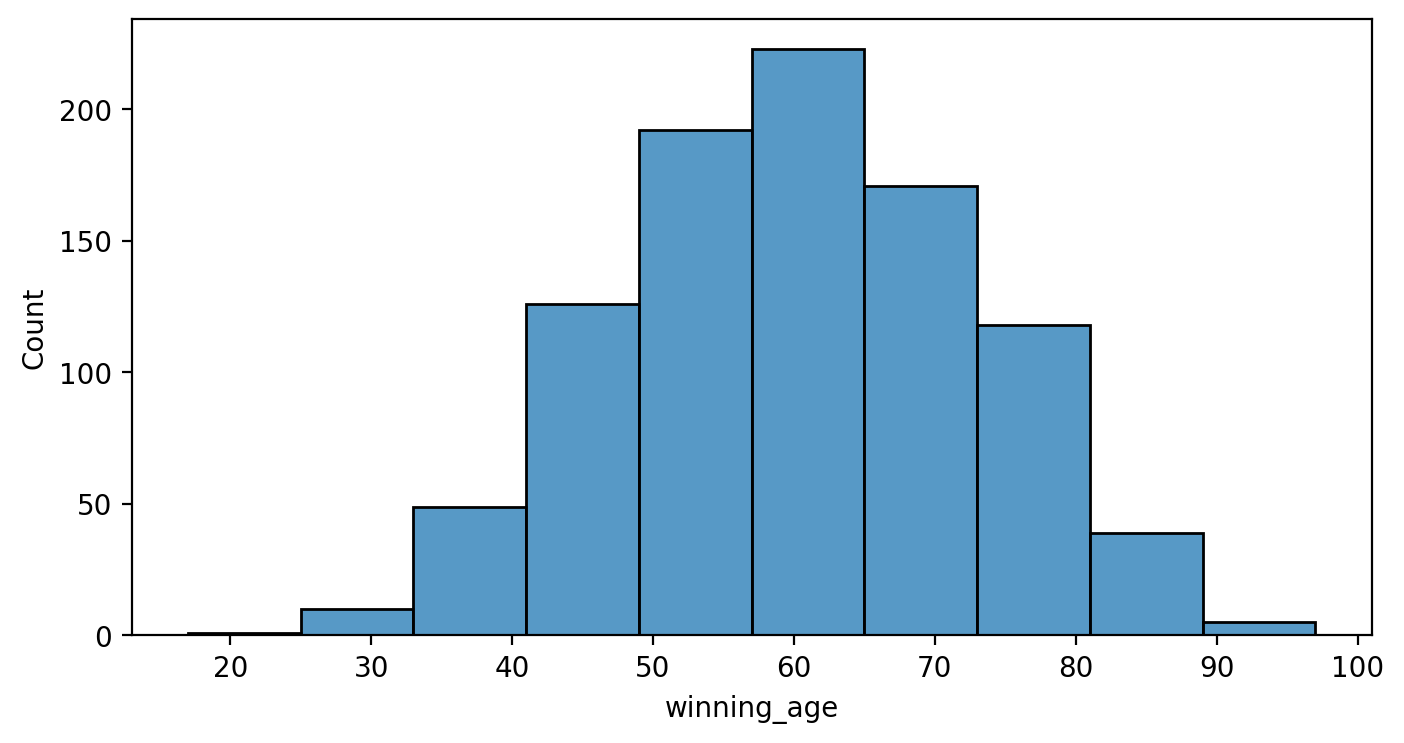

In [77]:
plt.figure(figsize=(8,4), dpi=200)
ax = sns.histplot (data=df_data,
                   x="winning_age",
                   bins=10)
plt.show()

### Age at Time of Award throughout History

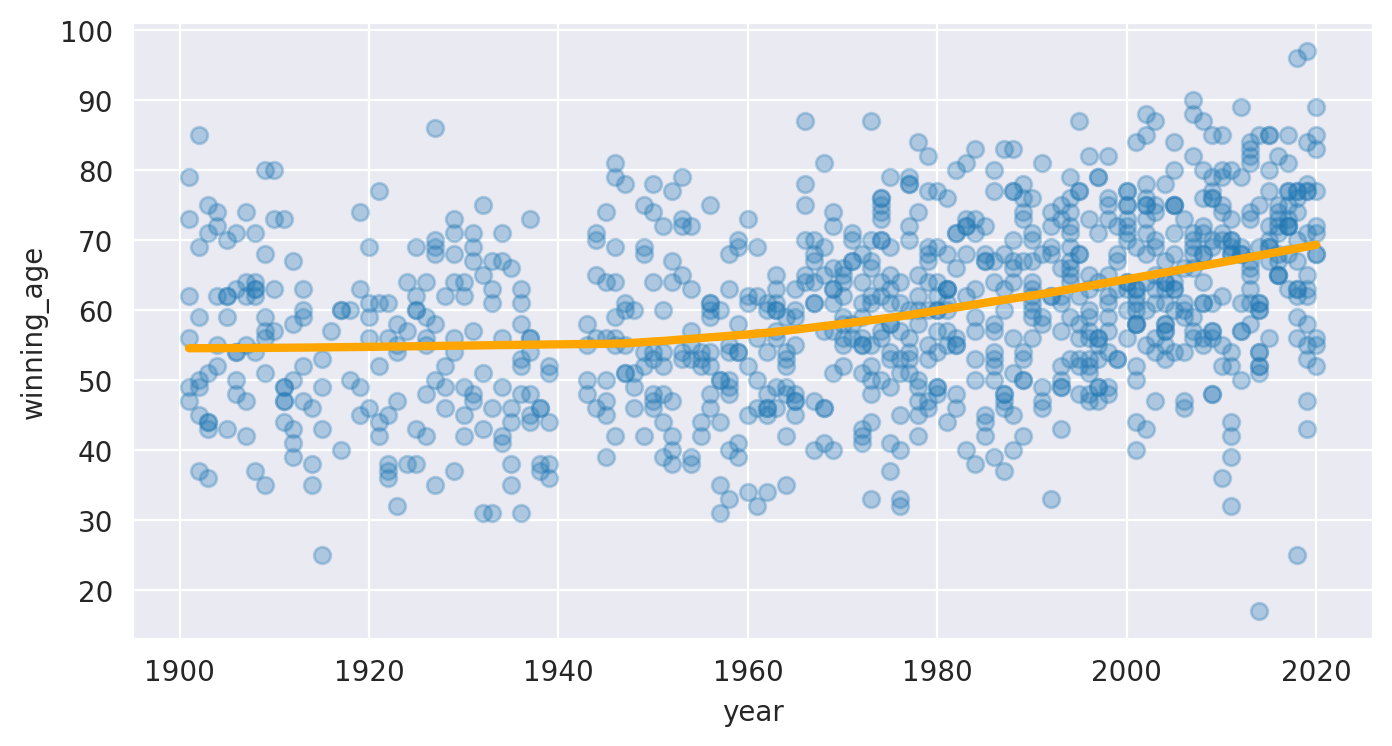

In [78]:
plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style("darkgrid"):
  ax = sns.regplot(data=df_data,
                  x="year",
                  y="winning_age",
                  scatter_kws={"alpha": 0.3},
                  line_kws={"color": "orange", "linewidth": 3},
                  lowess = True)
plt.show()

### Winning Age Across the Nobel Prize Categories

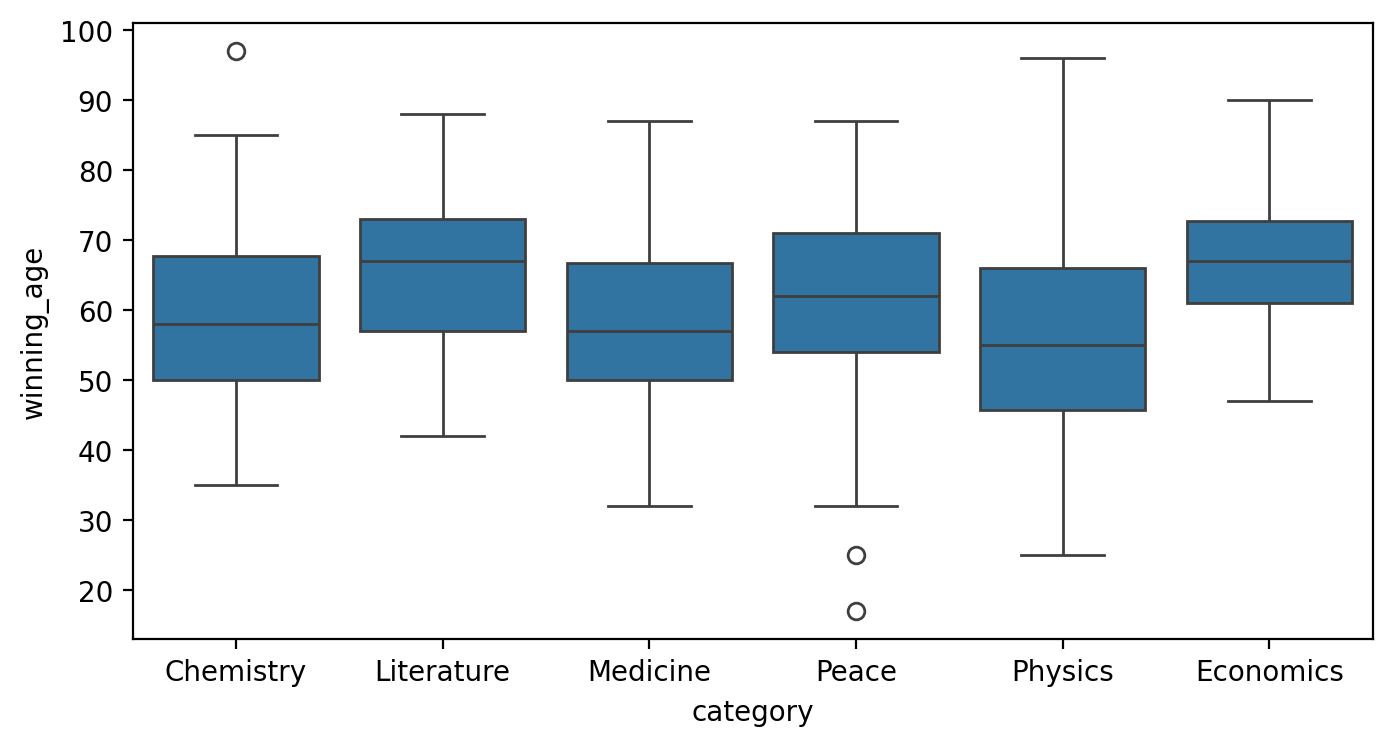

In [79]:
plt.figure(figsize=(8,4), dpi=200)
ax = sns.boxplot(data=df_data,
                 x="category",
                 y="winning_age")
plt.show()

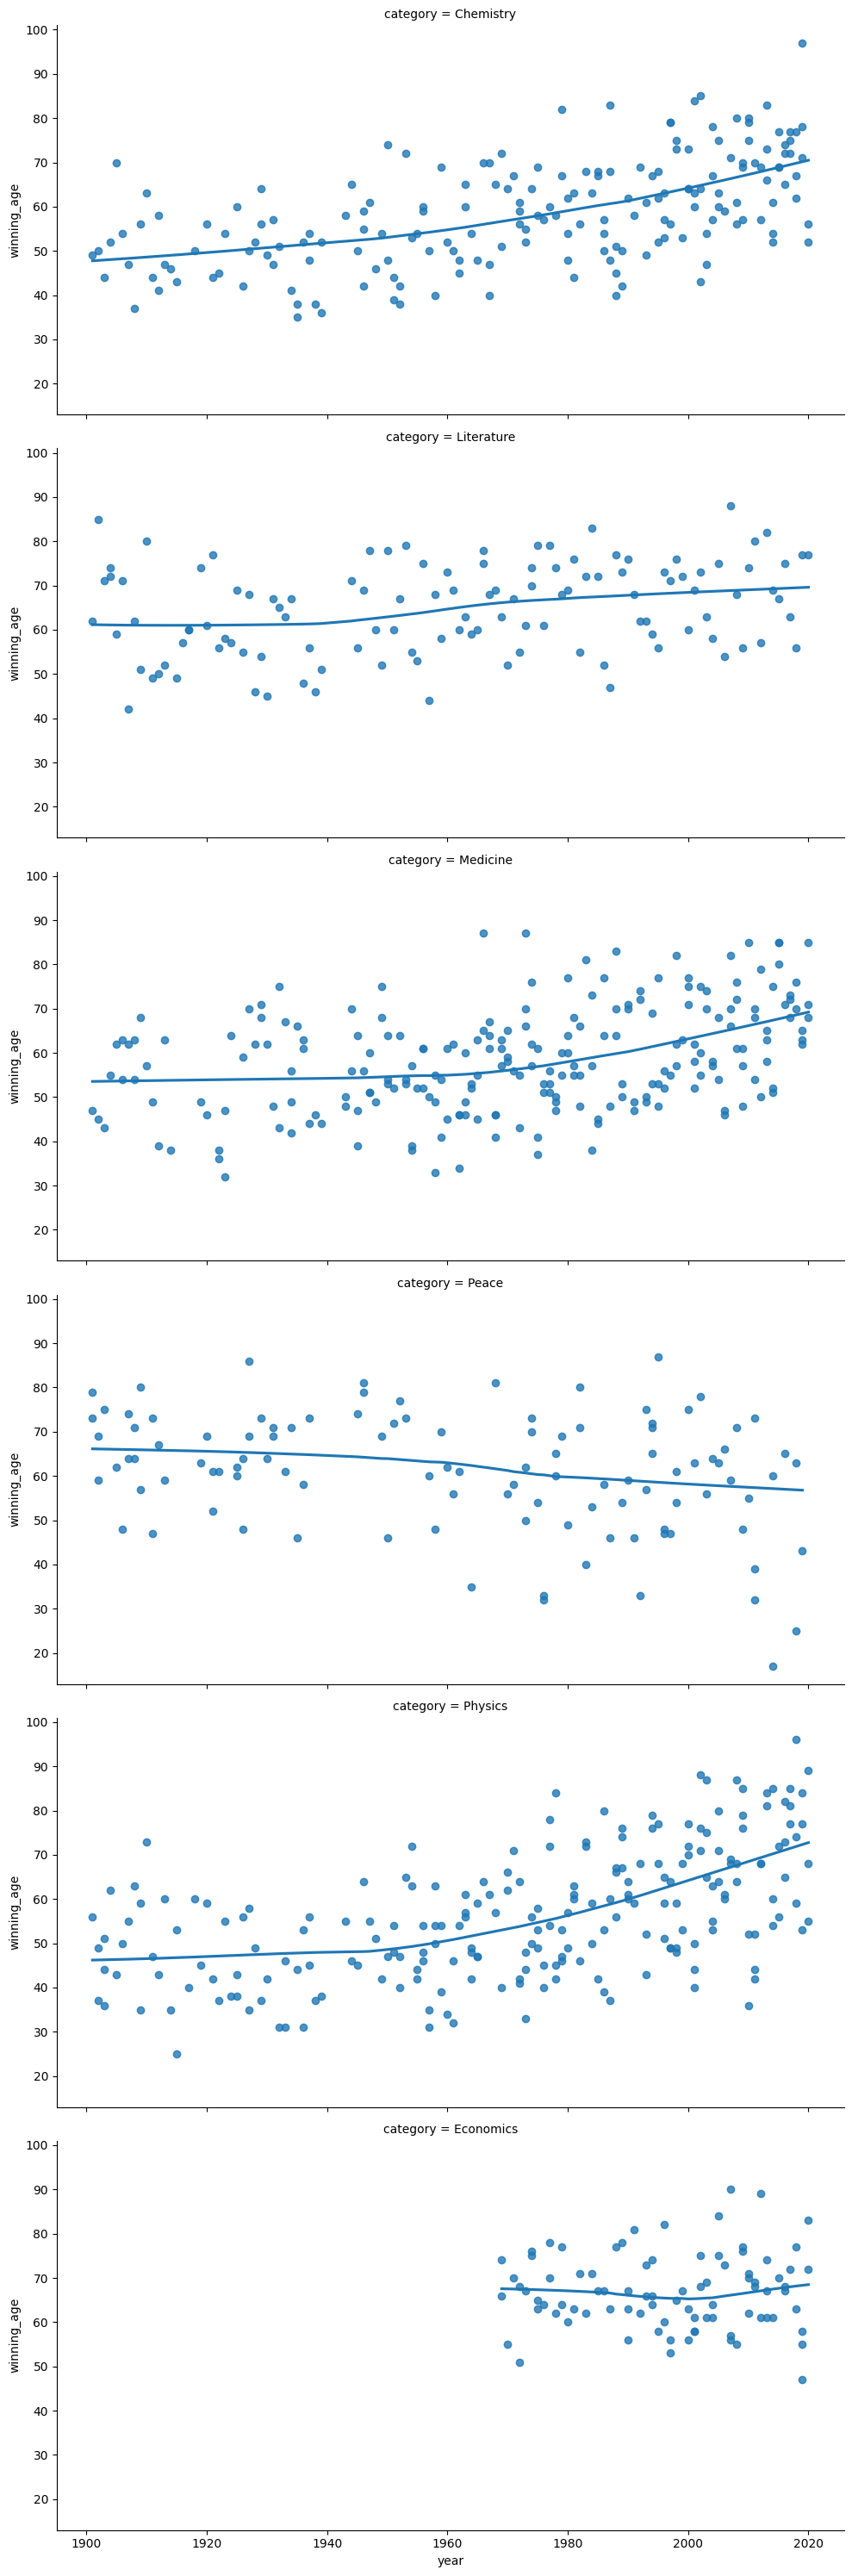

In [80]:
ax = sns.lmplot(data=df_data,
                x="year",
                y="winning_age",
                row="category",
                aspect=2,
                lowess=True)
plt.show()

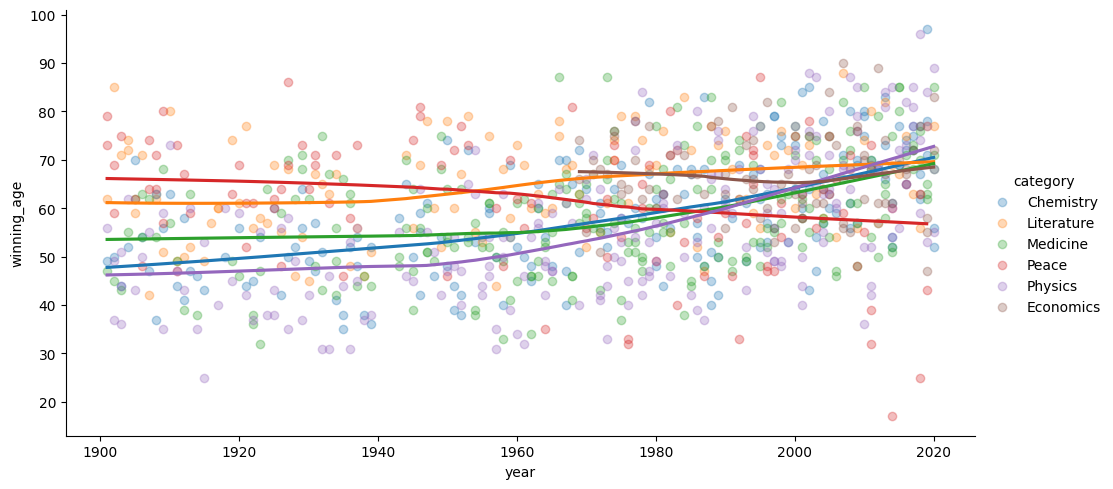

In [81]:
ax = sns.lmplot(data=df_data,
                x="year",
                y="winning_age",
                hue="category",
                lowess=True,
                aspect=2,
                scatter_kws={"alpha": 0.3})
plt.show()